In [2]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0AQQZFV2ALD" #fhr13-02
angle_profiles = ["0"]
workflow_name = "dent_detection_ae"

track_lists= [0,
        2,
        3,
        4,
        5,
        6,
        7,
        9,
        10,
        11,
        12,
        14,
        15,
        16,
        17,
        18,
        19,
        20,
        21,
        22,
        23
      ]
num_tracks = len(track_lists)
run_number = 13_02
environment = "prod" 

def prob_idx_to_track(prob_idx):
    """Map a probability array index to the actual track index."""
    if prob_idx < 0 or prob_idx >= len(track_lists):
        return -1
    return track_lists[prob_idx]

# def track_to_prob_idx(track_idx):
#     """Map an actual track index to the probability array index."""
#     try:
#         return track_lists.index(track_idx)
#     except ValueError:
#         return -1

In [2]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"/mnt/f/data-files/{inspection_id}/{workflow_name}"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0011", f"track_runs/{inspection_id}/{workflow_name}/", results_dir)

In [3]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [4]:
len(data_files), data_files

(783,
 [PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000000250.0_0000000500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000000500.0_0000000750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000000750.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000001000.0_0000001250.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000001250.0_0000001500.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000001500.0_0000001750.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD/dent_detection_ae/distance_0000001750.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('/mnt/f/data-files/0AQQZFV2ALD

In [5]:

import ast
# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

## Create a DataFrame for each profile and track and range
def create_df(frame_range=None, exclude_prob_indicies=[]):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]

    def read_and_validate(path):
        df = pd.read_csv(path)
        if df.empty:
            return df
        df['prob'] = df['prob'].apply(parse_prob)
        df = df[df['prob'].apply(lambda probs: any(p > 0.05 for p in probs))] 
        
        
        def max_prob_excluding_track(probs, exclude_indices=exclude_prob_indicies):
            if not probs:
                return 0, -1
            valid = [(p, i) for i, p in enumerate(probs) if i not in exclude_indices]
            if not valid:
                return 0, -1
            max_p, max_i = max(valid, key=lambda x: x[0])
            return max_p, max_i
        df['max_prob'] = df['prob'].apply(lambda probs: max_prob_excluding_track(probs)[0])
        df['max_prob_track'] = df['prob'].apply(lambda probs: max_prob_excluding_track(probs)[1])
        return df
    
    dfs = [df for df in (read_and_validate(path) for path in data_files_range) if not df.empty]

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [6]:
all_dfs = create_df(exclude_prob_indicies={9, 10, 11, 19})
display(all_dfs)

,start,end,prob,max_prob,max_prob_track
0,249.850000,250.150000,"[0.0004, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0029,18
1,250.000000,250.300000,"[0.1459, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.1459,0
2,250.150000,250.450000,"[0.2488, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.2488,0
3,250.300000,250.600000,"[0.0754, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0754,0
4,250.450000,250.750000,"[0.4985, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.4985,0
...,...,...,...,...,...
1649,249.416865,249.716865,"[0.0604, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0604,0
1650,249.566865,249.866865,"[0.0087, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0087,0
1651,249.716865,250.016865,"[0.3809, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.3809,0
1652,249.866865,250.166865,"[0.0005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.0005,0


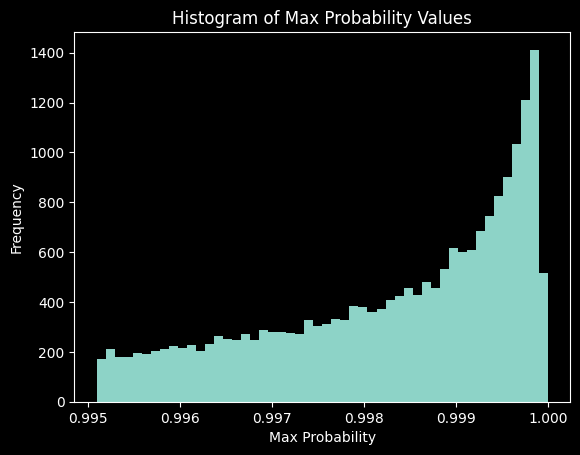

In [7]:
#make a histogram of all max_prob values
plt.style.use('dark_background')
plt.hist(all_dfs[all_dfs['max_prob']>0.995]['max_prob'], bins=50)
plt.xlabel('Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Values')
plt.show() 

Text(0.5, 1.0, 'Histogram of Max Probability Track Indices')

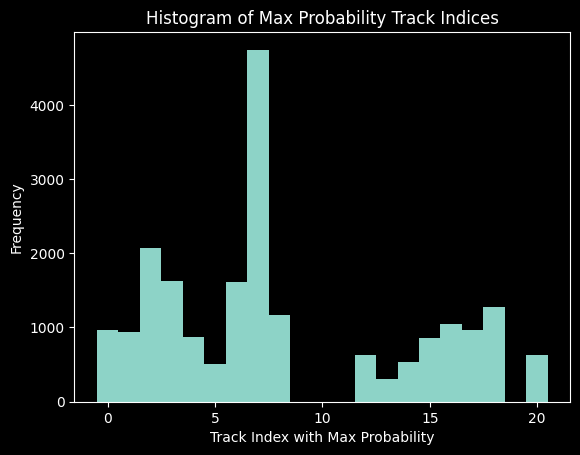

In [8]:
#make the histogram of max_prob_index values
plt.hist(all_dfs[all_dfs['max_prob']>0.995]['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices')

Filtered DF size: 4424


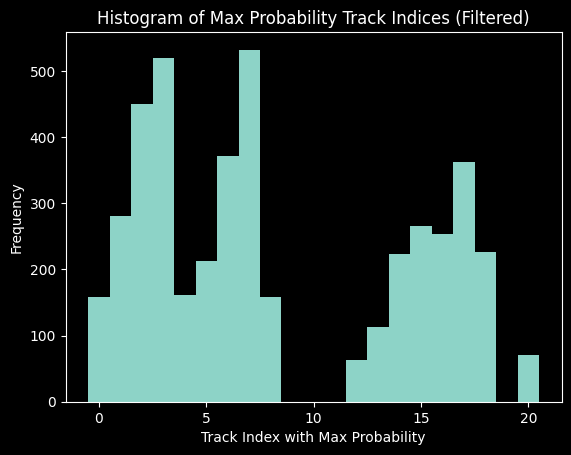

In [9]:
# Filter: keep if >=2 tracks have prob > th1, or exactly 1 track has prob > th2
multi_track_th1, multi_track_th2, single_track_th = 0.9,0.995, 1
def keep_row_by_probs(probs):
    if not probs:
        return False
    exclude = {19, 11, 9, 10}
    filtered = [p for i, p in enumerate(probs) if i not in exclude]
    n_multi_tracks = sum(1 for p in filtered if p > multi_track_th1)
    n_multi_tracks_th2 = sum(1 for p in filtered if p > multi_track_th2)
    n_single_track = sum(1 for p in filtered if p > single_track_th)
    if n_multi_tracks >= 3:
        return True
    if n_multi_tracks_th2 >= 2:
        return True
    if n_single_track == 1:
        return True
    return False
filtered_df = all_dfs[all_dfs['prob'].apply(keep_row_by_probs)].copy()
print(f"Filtered DF size: {len(filtered_df)}")
plt.hist(filtered_df['max_prob_track'], bins=num_tracks, range=(-0.5, num_tracks-0.5), align='mid')
plt.xlabel('Track Index with Max Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Max Probability Track Indices (Filtered)')
plt.show()

In [10]:
import numpy as np

def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with highest max_prob.
    
    Args:
        df: DataFrame with 'start' and 'max_prob' columns
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start descending
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Group detections within threshold
    starts = df_sorted['start'].values
    probs = df_sorted['max_prob'].values
    
    groups = []
    current_group = [0]
    
    for i in range(1, len(df_sorted)):
        # Check if within threshold of the first item in current group
        if starts[current_group[0]] - starts[i] < distance_threshold:
            current_group.append(i)
        else:
            # Finalize current group, keep highest prob
            groups.append(current_group)
            current_group = [i]
    
    # Don't forget the last group
    groups.append(current_group)
    
    # For each group, keep only the one with max prob
    kept_indices = []
    for group in groups:
        max_prob_idx = group[np.argmax(probs[group])]
        kept_indices.append(max_prob_idx)
    
    return df_sorted.iloc[kept_indices].reset_index(drop=True)

final_df = filter_close_detections(filtered_df)
print(f"Original df: {len(filtered_df)} rows")
print(f"final df: {len(final_df)} rows")

Original df: 4424 rows
final df: 3803 rows


In [11]:
#save final_df
final_df.to_parquet(f"./insp_{inspection_id}_final_df_ae.parquet", index=False)
display(final_df)

,start,end,prob,max_prob,max_prob_track
0,195545.600000,195545.900000,"[0.0, 0.0, 0.9995, 0.9998, 0.0, 0.0, 0.0, 0.0,...",0.9998,3
1,195423.100000,195423.400000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,13
2,195421.150000,195421.450000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9954,...",0.9999,8
3,195219.750000,195220.050000,"[0.0029, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.9990,17
4,195218.700000,195219.000000,"[0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.9992,16
...,...,...,...,...,...
3798,1505.100000,1505.400000,"[0.0, 0.0, 0.0031, 0.9999, 0.9965, 0.0, 0.0, 0...",0.9999,3
3799,1489.550000,1489.850000,"[0.0001, 0.0001, 0.0003, 0.0001, 0.0001, 0.000...",0.9991,17
3800,965.100000,965.400000,"[0.0, 0.0, 0.0, 0.0004, 0.9998, 0.9997, 0.0001...",0.9998,4
3801,940.200000,940.500000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0025, 0.99...",0.9999,8


In [12]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="std"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=max(track_lists)+1,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


Added /home/zmirikha/Github/rnd_q2 to Python path
Loading stub library for: libnppial.so.11
Loading stub library for: libnppig.so.11
Loading stub library for: libnppist.so.11
Loading stub library for: libnppc.so.11
PySettings.cpp(46): ilipy: Build 1.1.0.14279 380ca1bdb7 release-ili-1.1 'Tue Mar 24 17:54:38 2026'

PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

DatabaseWebSocket.cpp(153): WebSocket connection established to https://backend.ili-prod.da

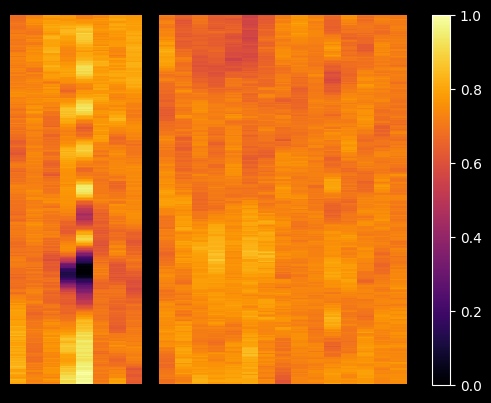

195545.74999999825 [0.0, 0.0, 0.9995, 0.9998, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


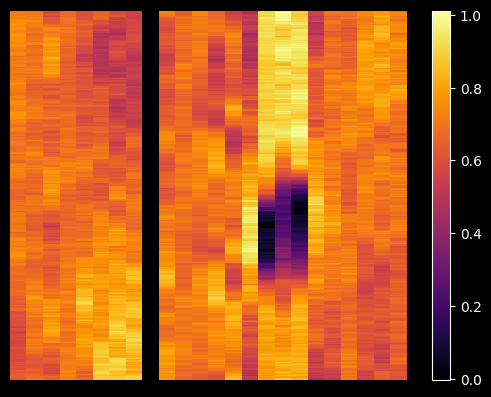

195423.24999999328 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0203, 0.9977, 0.9998, 0.9971, 0.0045, 0.0, 0.0, 0.0001, 0.0, 0.0]


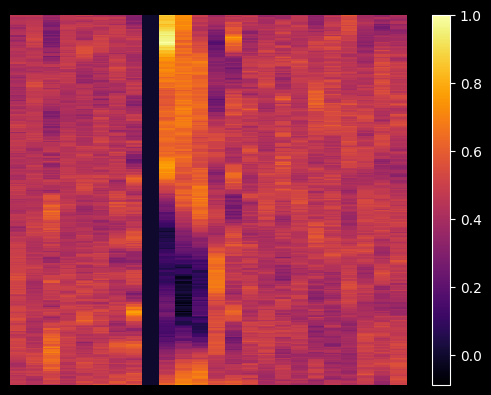

195421.29999999335 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9954, 0.9999, 0.9977, 0.0097, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:40085

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



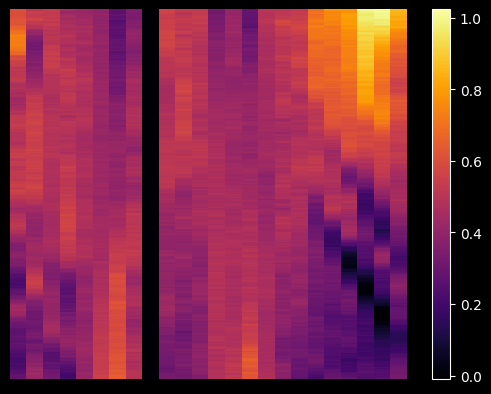

195219.89999999147 [0.0029, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0003, 0.8265, 0.999, 0.9976, 0.6729, 0.0002]


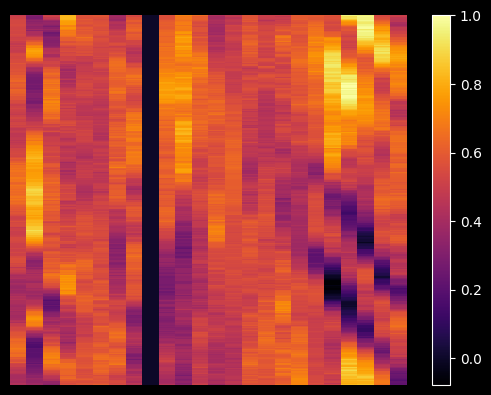

195218.8499999915 [0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9099, 0.9992, 0.6036, 0.9607, 0.1544, 0.0001]


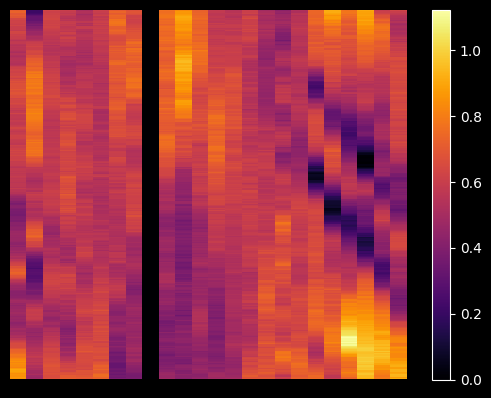

195217.49999999156 [0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9047, 0.9869, 0.801, 0.9972, 0.0644, 0.0]


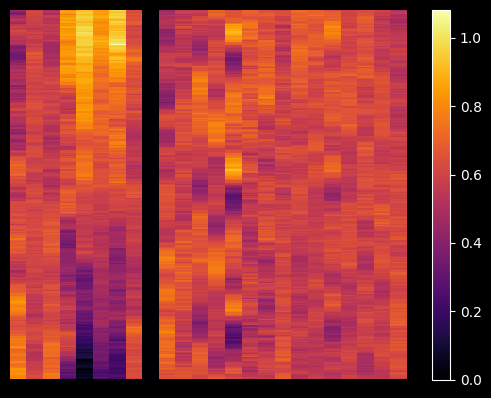

195211.79999999178 [0.0, 0.0001, 0.9256, 0.9961, 0.9456, 0.0009, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
ObserverHost.cpp(207): [ObserverHost] Registering with dv-observer at localhost:8000...

ObserverHost.cpp(212): [ObserverHost] Using listening server address localhost:40085

ObserverHost.cpp(250): [ObserverHost] Failed to register with dv-observer, response code: -1



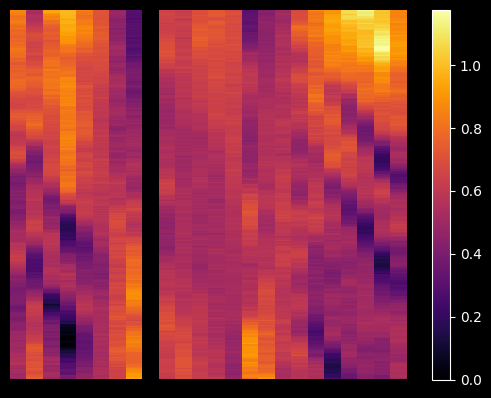

195200.6999999922 [0.0003, 0.9986, 0.9999, 0.0063, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0004, 0.0]


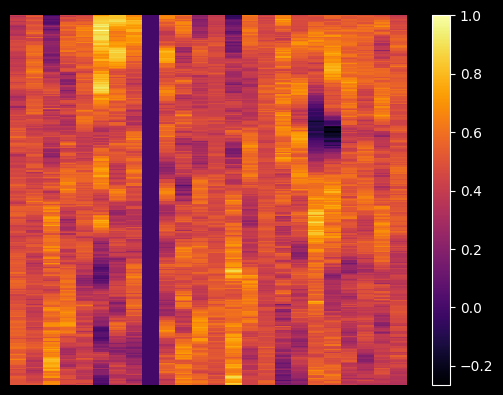

195164.09999999363 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0001, 0.0001, 0.9994, 0.9997, 0.0003, 0.0, 0.0, 0.0]


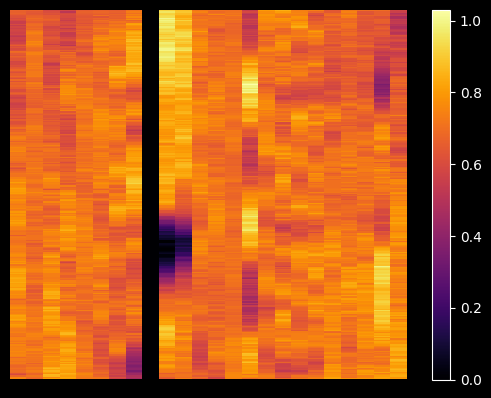

195132.44999999486 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0012, 0.9999, 0.9999, 0.0002, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [13]:
for i, row in final_df.head(10).iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

In [14]:
display(final_df)

,start,end,prob,max_prob,max_prob_track
0,195545.600000,195545.900000,"[0.0, 0.0, 0.9995, 0.9998, 0.0, 0.0, 0.0, 0.0,...",0.9998,3
1,195423.100000,195423.400000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,13
2,195421.150000,195421.450000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9954,...",0.9999,8
3,195219.750000,195220.050000,"[0.0029, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.9990,17
4,195218.700000,195219.000000,"[0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.9992,16
...,...,...,...,...,...
3798,1505.100000,1505.400000,"[0.0, 0.0, 0.0031, 0.9999, 0.9965, 0.0, 0.0, 0...",0.9999,3
3799,1489.550000,1489.850000,"[0.0001, 0.0001, 0.0003, 0.0001, 0.0001, 0.000...",0.9991,17
3800,965.100000,965.400000,"[0.0, 0.0, 0.0, 0.0004, 0.9998, 0.9997, 0.0001...",0.9998,4
3801,940.200000,940.500000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0025, 0.99...",0.9999,8


## Insert Anomalies

In [15]:
from ilipy import ClipTypes, Session, TrackIndex, ViewDistance
from ilipy.channeldata import ImageProfile
from ilipy.features import Bookmarks
from ilipyutils.ml_features.base import get_ml_models_info_list, AnomalyStatus
from ilipyutils.ml_features.insert import FeatureInsert, GeometryCubeParameters
from ili_custom_data.load_model import ModelDataLoader
from ilipy.database import DistanceCorrelation

session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
bookmarks_interface = Bookmarks(session=session)
feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)
latest_model = ModelDataLoader.get_latest_model()

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-02.darkvision.local, Port: 8070, Concurrent Connections: 1

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-02.darkvision.local:8070) : 200, 51ms

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-01.darkvision.local:8070) : 200, 53ms

RestApi.cpp(84): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8070) : -1, 270ms

RequestPool.cpp(303): Failed to acquire c

In [16]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 100) / 100
    # The upper bound is just 0.01 more
    upper = round(lower + 0.01, 2)

    return lower, upper

In [17]:
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(200-(1.9/2), 200+(1.9/2)),
)
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info

MLModelInfo(model_name='Dent-Detection-v3', model_id=12, model_score_bound=[0, 1], anomaly_type_name='DentPlain')

In [31]:
i=0
for i, row in final_df.iterrows():

        print(f"uploading row {i+1} of {len(final_df)}")
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, _ , max_prob, max_prob_track = row['start'], row['end'], row['prob'], row['max_prob'], row['max_prob_track']
        actual_track_idx = prob_idx_to_track(max_prob_track)
        print(actual_track_idx)

        start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(actual_track_idx), ViewDistance(vd_start)).value
        end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(actual_track_idx), ViewDistance(vd_end)).value
        model_instance = latest_model(
        ml_confidence_score=max_prob,)
        lower_bound, upper_bound = get_decimal_range(max_prob)
        extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
        model_instance = latest_model(
        ml_confidence_score=max_prob,)
        print(extra_tags)


#         anomaly_info = feature_insert.insert_ml_pred(
#         inspection_id=inspection_id,
#         tlbr_track_indices=[actual_track_idx,actual_track_idx],
#         tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
#         cube_params=cube_params,
#         model_info=model_info,
#         anomaly_status=AnomalyStatus.REVIEW_DETECTION,
#         image_profile=profile,
#         extra_tags=extra_tags,
#         ili_custom_data=model_instance
#        )





uploading row 1 of 3803
4
{'threshold_bin-0.99-1.0'}
uploading row 2 of 3803
16
{'threshold_bin-0.99-1.0'}
uploading row 3 of 3803
10
{'threshold_bin-0.99-1.0'}
uploading row 4 of 3803
20
{'threshold_bin-0.99-1.0'}
uploading row 5 of 3803
19
{'threshold_bin-0.99-1.0'}
uploading row 6 of 3803
21
{'threshold_bin-0.99-1.0'}
uploading row 7 of 3803
4
{'threshold_bin-0.99-1.0'}
uploading row 8 of 3803
3
{'threshold_bin-0.99-1.0'}
uploading row 9 of 3803
19
{'threshold_bin-0.99-1.0'}
uploading row 10 of 3803
9
{'threshold_bin-0.99-1.0'}
uploading row 11 of 3803
15
{'threshold_bin-0.99-1.0'}
uploading row 12 of 3803
2
{'threshold_bin-0.99-1.0'}
uploading row 13 of 3803
10
{'threshold_bin-0.99-1.0'}
uploading row 14 of 3803
5
{'threshold_bin-0.99-1.0'}
uploading row 15 of 3803
4
{'threshold_bin-0.99-1.0'}
uploading row 16 of 3803
5
{'threshold_bin-0.99-1.0'}
uploading row 17 of 3803
6
{'threshold_bin-0.99-1.0'}
uploading row 18 of 3803
6
{'threshold_bin-0.99-1.0'}
uploading row 19 of 3803
4
{'

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

CognitoAuthentic

In [ ]:
# from ilipy import OdometerTicks, ViewDistance
# from ilipy.channeldata import ImageProfile
# from ilipy.database import DistanceCorrelation
# from ilipy.features import (
#     AnomalyInfo,
#     AnomalyStatusTypeEnum,
#     CorrosionAnomalyProperties,
#     GeometryBoundingCube,
#     GeometryCubePoint,
#     JointInfo,
#     SurfaceLocationType,
# )
# from ilipyutils.configs import FF_DEFAULTS

In [ ]:
# feat_list = [vd_start, vd_end, max_prob, max_prob_track]
# def create_anomaly(
#     feat_list, inspection_id: str #, required_tag: str | None
# ):  
#     start_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[0])).value
#     end_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(feat_list[3]), ViewDistance(feat_list[1])).value
       
#     anomaly = AnomalyInfo()
#     anomaly.feature.inspection_id = inspection_id
#     unique_name = "{}_{}_{}".format(
#         feat_list[3],
#         str(start_odo_ticks),
#         str(end_odo_ticks),
#     )
#     anomaly.feature.name = unique_name
#     # if required_tag:
#     #     anomaly.tags = {required_tag}.union(set(sizing_result["wall_location"]))
#     # else:
#     #     anomaly.tags = set(sizing_result["wall_location"])
#     anomaly.feature.anomaly_identification_type_id = 303
#     anomaly.feature.anomaly_status_type_id = 1

#     # circles = xr.DataArray(
#     #     np.stack(
#     #         [
#     #             np.array(sizing_result["circle_z"]),
#     #             np.array(sizing_result["circle_y"]),
#     #             np.array(sizing_result["circle_r"]),
#     #         ],
#     #         axis=1,
#     #     ),
#     #     coords=LogicalCoordinates.odo_ticks(sizing_result["circle_odo_tick"]),
#     #     dims=[LogicalCoordinates.odo_ticks.dim, "results"],
#     # )
#     # populate_anomaly_with_circles(  # need to make frame start index right
#     #     anomaly=anomaly,
#     #     circles=circles,
#     #     start_frame_idx=sizing_result[
#     #         "circle_start_frame"
#     #     ],  # need original start frame index here
#     # )

#     bm_cube = GeometryBoundingCube(
#         image_profile=ImageProfile.ZeroAngle,
#         top_left=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=199,
#             cube_angle_rad=np.deg2rad(5),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][0],
#             odometer_ticks=OdometerTicks(start_odo_ticks),
#         ),
#         bottom_right=GeometryCubePoint(
#             track_index=feat_list[3],
#             radial_position_mm=201,
#             cube_angle_rad=np.deg2rad(15),
#             probe_scan_angle_rad=FF_DEFAULTS["angle_range_radians"][-1],
#             odometer_ticks=OdometerTicks(end_odo_ticks),
#         ),
#     )


#     anomaly.feature.geometry = bm_cube
#     anomaly.feature.anomaly_status = AnomalyStatusTypeEnum.ReviewDetection

#     return anomaly



In [1]:
from ilipy import ViewDistance, PipeDistance

def add_pipe_distances(df, dist_corr, 
                       view_distance_start_col='view_distance_start', 
                       view_distance_stop_col='view_distance_stop'):
    """
    Add pipe_distance_start and pipe_distance_stop columns to a DataFrame
    by converting view distances to pipe distances using anchor-based correlation.
    
    Args:
        df: DataFrame with view distance columns
        dist_corr: DistanceCorrelation object from ilipy
        view_distance_start_col: column name for start view distance
        view_distance_stop_col: column name for stop view distance
    
    Returns:
        DataFrame with added pipe_distance_start and pipe_distance_stop columns
    """
    if df is None or len(df) == 0:
        return df
    
    df = df.copy()
    df['pipe_distance_start'] = np.nan
    df['pipe_distance_stop'] = np.nan
    
    for idx, row in df.iterrows():
        try:
            vd_start = row[view_distance_start_col]
            vd_stop = row[view_distance_stop_col]
            
            if pd.notna(vd_start):
                pd_start = dist_corr.get_pipe_distance_from_view_distance(
                    ViewDistance(float(vd_start))
                ).value
                df.loc[idx, 'pipe_distance_start'] = pd_start
            
            if pd.notna(vd_stop):
                pd_stop = dist_corr.get_pipe_distance_from_view_distance(
                    ViewDistance(float(vd_stop))
                ).value
                df.loc[idx, 'pipe_distance_stop'] = pd_stop
                
        except Exception as e:
            print(f"Error processing row {idx}: {e}")
            continue
    
    return df

Loading stub library for: libnppial.so.11
Loading stub library for: libnppig.so.11
Loading stub library for: libnppist.so.11
Loading stub library for: libnppc.so.11


In [6]:
from ilipy import Session
from ilipy.database import DistanceCorrelation
import numpy as np
session = Session(environment=environment)
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

final_ae = pd.read_parquet("/home/zmirikha/Github/rnd_q2/inference/ilit0013/ilit0013-02/insp_0AQQZFV2ALD_final_df_ae.parquet")
display(final_ae)

df_with_final_track_writh_PD = add_pipe_distances(final_ae, dist_corr, view_distance_start_col='start', view_distance_stop_col='end')
display(df_with_final_track_writh_PD)
df_with_final_track_writh_PD.to_parquet(f"./insp_{inspection_id}_final_df_ae_with_pipe_distances.parquet", index=False)


PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.

CognitoAuthenticator.cpp(158): Using Cognito Credentials

CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8070, Concurrent Connections: 1

RequestPool.cpp(84): [HttpRequestPool] Host: dvv-storage-02.darkvision.local, Port: 8070, Concurrent Connections: 1

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-02.darkvision.local:8070) : 200, 17ms

RestApi.cpp(84): ApiService Ping Response (http://dvv-storage-01.darkvision.local:8070) : 200, 32ms

RequestPool.cpp(303): Failed to acquire connection: http://storage-dvh-01.darkvision.local:8070/ping GET code: 1048, value: AWS_IO_SOCKET_TIME

,start,end,prob,max_prob,max_prob_track
0,195545.600000,195545.900000,"[0.0, 0.0, 0.9995, 0.9998, 0.0, 0.0, 0.0, 0.0,...",0.9998,3
1,195423.100000,195423.400000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,13
2,195421.150000,195421.450000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9954,...",0.9999,8
3,195219.750000,195220.050000,"[0.0029, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.9990,17
4,195218.700000,195219.000000,"[0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.9992,16
...,...,...,...,...,...
3798,1505.100000,1505.400000,"[0.0, 0.0, 0.0031, 0.9999, 0.9965, 0.0, 0.0, 0...",0.9999,3
3799,1489.550000,1489.850000,"[0.0001, 0.0001, 0.0003, 0.0001, 0.0001, 0.000...",0.9991,17
3800,965.100000,965.400000,"[0.0, 0.0, 0.0, 0.0004, 0.9998, 0.9997, 0.0001...",0.9998,4
3801,940.200000,940.500000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0025, 0.99...",0.9999,8


,start,end,prob,max_prob,max_prob_track,pipe_distance_start,pipe_distance_stop
0,195545.600000,195545.900000,"[0.0, 0.0, 0.9995, 0.9998, 0.0, 0.0, 0.0, 0.0,...",0.9998,3,195594.795694,195595.095430
1,195423.100000,195423.400000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.9998,13,195473.212978,195473.510323
2,195421.150000,195421.450000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9954,...",0.9999,8,195471.280233,195471.577578
3,195219.750000,195220.050000,"[0.0029, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.9990,17,195271.412340,195271.709193
4,195218.700000,195219.000000,"[0.001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",0.9992,16,195270.373352,195270.670206
...,...,...,...,...,...,...,...
3798,1505.100000,1505.400000,"[0.0, 0.0, 0.0031, 0.9999, 0.9965, 0.0, 0.0, 0...",0.9999,3,1605.751122,1606.076388
3799,1489.550000,1489.850000,"[0.0001, 0.0001, 0.0003, 0.0001, 0.0001, 0.000...",0.9991,17,1588.987713,1589.309310
3800,965.100000,965.400000,"[0.0, 0.0, 0.0, 0.0004, 0.9998, 0.9997, 0.0001...",0.9998,4,1022.403143,1022.728376
3801,940.200000,940.500000,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0025, 0.99...",0.9999,8,995.405262,995.730588


CognitoAuthenticator.cpp(842): Login Successful.

CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji

